In [2]:
# clean_xml.py

import os
import xml.etree.ElementTree as ET

def clean_and_update_metadata(root_folder_path):
    # 1. 파일 경로 설정
    xml_path = os.path.join(root_folder_path, 'annotations.xml')
    images_folder = os.path.join(root_folder_path, 'images')
    output_xml_path = os.path.join(root_folder_path, 'annotations_cleaned.xml')

    # 2. 파일 존재 확인
    if not os.path.exists(xml_path):
        print(f"❌ 오류: '{xml_path}' 파일을 찾을 수 없습니다.")
        return
    if not os.path.exists(images_folder):
        print(f"❌ 오류: '{images_folder}' 폴더를 찾을 수 없습니다.")
        return

    print(f"📂 작업 시작: {root_folder_path}")
    
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except ET.ParseError as e:
        print(f"❌ XML 파싱 오류: {e}")
        return

    # 3. 이미지 태그 순회 및 정리 (유효 이미지 선별)
    xml_images = root.findall('image')
    
    new_id = 0          # 새로 부여할 ID (0부터 시작)
    removed_count = 0   # 삭제된 이미지 수
    kept_count = 0      # 유지된 이미지 수

    for image in xml_images:
        filename = image.get('name')
        full_image_path = os.path.join(images_folder, filename)

        if os.path.exists(full_image_path):
            # 파일이 존재하면 ID 재할당 (0, 1, 2...)
            image.set('id', str(new_id))
            new_id += 1
            kept_count += 1
        else:
            # 파일이 없으면 XML에서 제거
            root.remove(image)
            removed_count += 1

    # 유효한 이미지가 하나도 없으면 중단
    if kept_count == 0:
        print("❌ 오류: 유효한 이미지가 하나도 남지 않았습니다.")
        return

    # 4. 메타데이터(Meta) 업데이트
    # (1) <size>: 전체 이미지 개수
    size_tag = root.find('.//meta/task/size')
    if size_tag is not None:
        print(f"   ℹ️ [size] 업데이트: {size_tag.text} -> {kept_count}")
        size_tag.text = str(kept_count)

    # (2) <stop_frame>: 마지막 인덱스 (개수 - 1)
    stop_frame_tag = root.find('.//meta/task/stop_frame')
    if stop_frame_tag is not None:
        new_stop_frame = kept_count - 1
        print(f"   ℹ️ [stop_frame] 업데이트: {stop_frame_tag.text} -> {new_stop_frame}")
        stop_frame_tag.text = str(new_stop_frame)

    # (3) <segments><segment><stop>: 세그먼트 종료 인덱스 (개수 - 1)
    # 보통 CVAT XML에는 하나의 segment만 있는 경우가 많지만, 혹시 모르니 모두 순회
    segments = root.findall('.//meta/task/segments/segment')
    for seg in segments:
        stop_tag = seg.find('stop')
        if stop_tag is not None:
            new_stop = kept_count - 1
            print(f"   ℹ️ [segment/stop] 업데이트: {stop_tag.text} -> {new_stop}")
            stop_tag.text = str(new_stop)

    # 5. 저장
    tree.write(output_xml_path, encoding='utf-8', xml_declaration=True)

    # --- 결과 리포트 ---
    print("\n" + "=" * 40)
    print("✅ 메타데이터 및 인덱스 정리 완료!")
    print(f"   - 기존 이미지 수 : {len(xml_images)} 개")
    print(f"   - 삭제된 이미지  : {removed_count} 개")
    print(f"   - 최종 이미지 수 : {kept_count} 개")
    print(f"   - 최종 ID 범위   : 0 ~ {kept_count - 1}")
    print(f"   - 저장 파일명    : {output_xml_path}")
    print("=" * 40)

# --- 실행 ---
# 폴더 경로를 본인 환경에 맞게 수정해주세요.
clean_and_update_metadata('./dataset_cvat_cp')

📂 작업 시작: ./dataset_cvat_cp
   ℹ️ [size] 업데이트: 409 -> 398
   ℹ️ [stop_frame] 업데이트: 408 -> 397
   ℹ️ [segment/stop] 업데이트: 408 -> 397

✅ 메타데이터 및 인덱스 정리 완료!
   - 기존 이미지 수 : 398 개
   - 삭제된 이미지  : 0 개
   - 최종 이미지 수 : 398 개
   - 최종 ID 범위   : 0 ~ 397
   - 저장 파일명    : ./dataset_cvat_cp\annotations_cleaned.xml


In [3]:
# rotate_fix.py

import os
import math
import xml.etree.ElementTree as ET
from PIL import Image

def rotate_and_update(root_folder_path):
    # 1. 경로 설정
    xml_path = os.path.join(root_folder_path, 'annotations_cleaned.xml') # 이전 단계 결과물 사용
    images_root = os.path.join(root_folder_path, 'images')
    
    # 하위 폴더 경로
    dir_90 = os.path.join(images_root, 'rotate_90')
    dir_180 = os.path.join(images_root, 'rotate_180')
    
    output_xml_path = os.path.join(root_folder_path, 'annotations_final.xml')

    # 2. XML 로드
    if not os.path.exists(xml_path):
        print(f"❌ 오류: '{xml_path}' 파일을 찾을 수 없습니다. 이전 단계의 cleaned 파일을 확인해주세요.")
        return

    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception as e:
        print(f"❌ XML 파싱 오류: {e}")
        return

    # XML 검색 속도를 높이기 위해 filename -> image element 매핑 생성
    xml_image_map = {img.get('name'): img for img in root.findall('image')}
    
    processed_count = 0

    # --- 내부 함수: 좌표 회전 로직 ---
    def transform_box(box, transform_type, img_w, img_h):
        # 현재 좌표 가져오기 (float 형변환)
        xtl = float(box.get('xtl'))
        ytl = float(box.get('ytl'))
        xbr = float(box.get('xbr'))
        ybr = float(box.get('ybr'))

        new_xtl, new_ytl, new_xbr, new_ybr = 0, 0, 0, 0

        if transform_type == 90:
            # 시계 방향 90도 회전 공식
            # (x, y) -> (H - y, x)
            # 회전 후에는 가로/세로가 바뀌므로 img_h가 새로운 너비의 기준이 됨
            
            # 1. 4개의 코너 좌표 변환
            points = [
                (img_h - ytl, xtl), # top-left 변환
                (img_h - ybr, xbr)  # bottom-right 변환
            ]
            # 2. Box 정규화 (Min, Max 재설정)
            xs = [p[0] for p in points]
            ys = [p[1] for p in points]
            
            new_xtl, new_xbr = min(xs), max(xs)
            new_ytl, new_ybr = min(ys), max(ys)

        elif transform_type == 180:
            # 180도 회전 공식
            # (x, y) -> (W - x, H - y)
            points = [
                (img_w - xtl, img_h - ytl),
                (img_w - xbr, img_h - ybr)
            ]
            xs = [p[0] for p in points]
            ys = [p[1] for p in points]
            
            new_xtl, new_xbr = min(xs), max(xs)
            new_ytl, new_ybr = min(ys), max(ys)

        # 값 업데이트 (.2f로 포맷팅)
        box.set('xtl', f"{new_xtl:.2f}")
        box.set('ytl', f"{new_ytl:.2f}")
        box.set('xbr', f"{new_xbr:.2f}")
        box.set('ybr', f"{new_ybr:.2f}")

    # --- 메인 처리 로직 ---
    
    # 3. 90도 회전 (rotate_90 폴더)
    if os.path.exists(dir_90):
        print(f"🔄 [90도 회전] 처리 시작: {dir_90}")
        for filename in os.listdir(dir_90):
            full_path = os.path.join(dir_90, filename)
            
            # 이미지 파일인지 확인
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            
            # A. XML 정보 수정
            if filename in xml_image_map:
                img_elem = xml_image_map[filename]
                w = float(img_elem.get('width'))
                h = float(img_elem.get('height'))
                
                # 90도 회전 시 이미지의 W, H가 바뀜 (Swap)
                img_elem.set('width', str(int(h)))
                img_elem.set('height', str(int(w)))
                
                # Box 좌표 수정
                for box in img_elem.findall('box'):
                    transform_box(box, 90, w, h)
                
                processed_count += 1
            
            # B. 실제 이미지 회전 및 저장 (덮어쓰기)
            try:
                with Image.open(full_path) as img:
                    # PIL의 rotate(-90)이 시계방향 90도, expand=True로 캔버스 크기 조정
                    rotated_img = img.rotate(-90, expand=True)
                    rotated_img.save(full_path)
                    print(f"   ✅ {filename} : 이미지 회전 & 좌표 수정 완료")
            except Exception as e:
                print(f"   ❌ {filename} 이미지 처리 실패: {e}")

    # 4. 180도 회전 (rotate_180 폴더)
    if os.path.exists(dir_180):
        print(f"\n🔄 [180도 회전] 처리 시작: {dir_180}")
        for filename in os.listdir(dir_180):
            full_path = os.path.join(dir_180, filename)
            
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            
            # A. XML 정보 수정
            if filename in xml_image_map:
                img_elem = xml_image_map[filename]
                w = float(img_elem.get('width'))
                h = float(img_elem.get('height'))
                
                # 180도 회전은 W, H 유지
                
                # Box 좌표 수정
                for box in img_elem.findall('box'):
                    transform_box(box, 180, w, h)
                
                processed_count += 1

            # B. 실제 이미지 회전 및 저장
            try:
                with Image.open(full_path) as img:
                    rotated_img = img.rotate(180, expand=True)
                    rotated_img.save(full_path)
                    print(f"   ✅ {filename} : 이미지 회전 & 좌표 수정 완료")
            except Exception as e:
                print(f"   ❌ {filename} 이미지 처리 실패: {e}")

    # 5. 결과 XML 저장
    tree.write(output_xml_path, encoding='utf-8', xml_declaration=True)
    
    print("\n" + "=" * 50)
    print("🎉 모든 작업 완료!")
    print(f"   - 총 처리된 이미지 수: {processed_count}")
    print(f"   - 수정된 XML 파일: {output_xml_path}")
    print("⚠️ 주의: 이미지 파일 자체가 수정되었습니다.")
    print("=" * 50)

# --- 실행 ---
# dataset_cvat_cp 폴더 경로 입력
# rotate_90, rotate_180 폴더가 images 폴더 안에 있어야 함
rotate_and_update('./dataset_cvat_cp')

🔄 [90도 회전] 처리 시작: ./dataset_cvat_cp\images\rotate_90
   ✅ 250404_img_000.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_001.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_002.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_003.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_004.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_005.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_006.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_007.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_008.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_009.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_010.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_011.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_012.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_013.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_014.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_015.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_016.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_022.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_024.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_025.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_026.png : 이미지 회전 & 좌표 수정 완료
   ✅ 250404_img_027.png


🔍 [rotate_90] 검증 시작 (3장)...


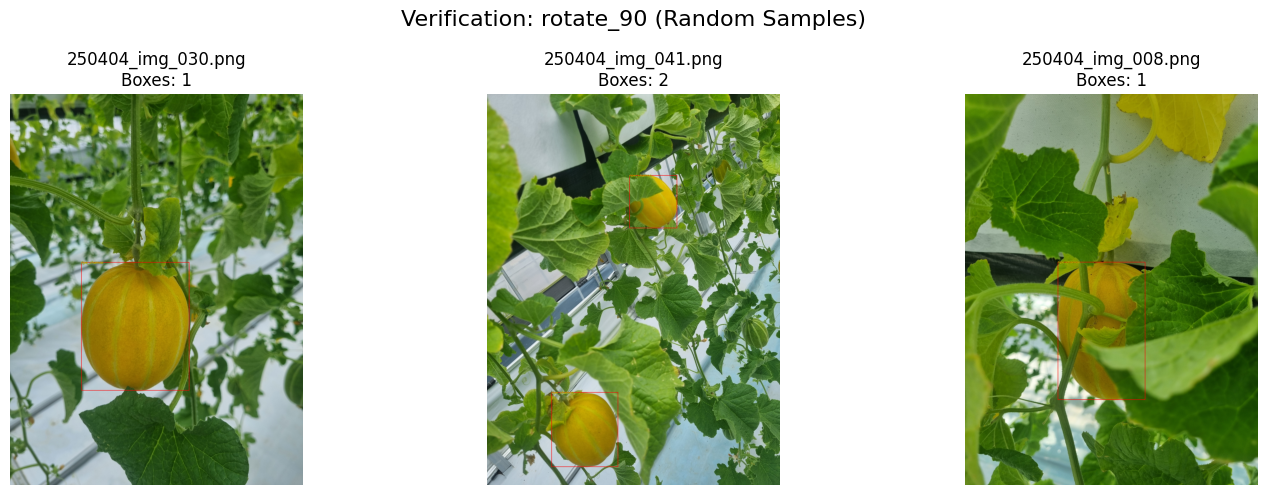


🔍 [rotate_180] 검증 시작 (3장)...


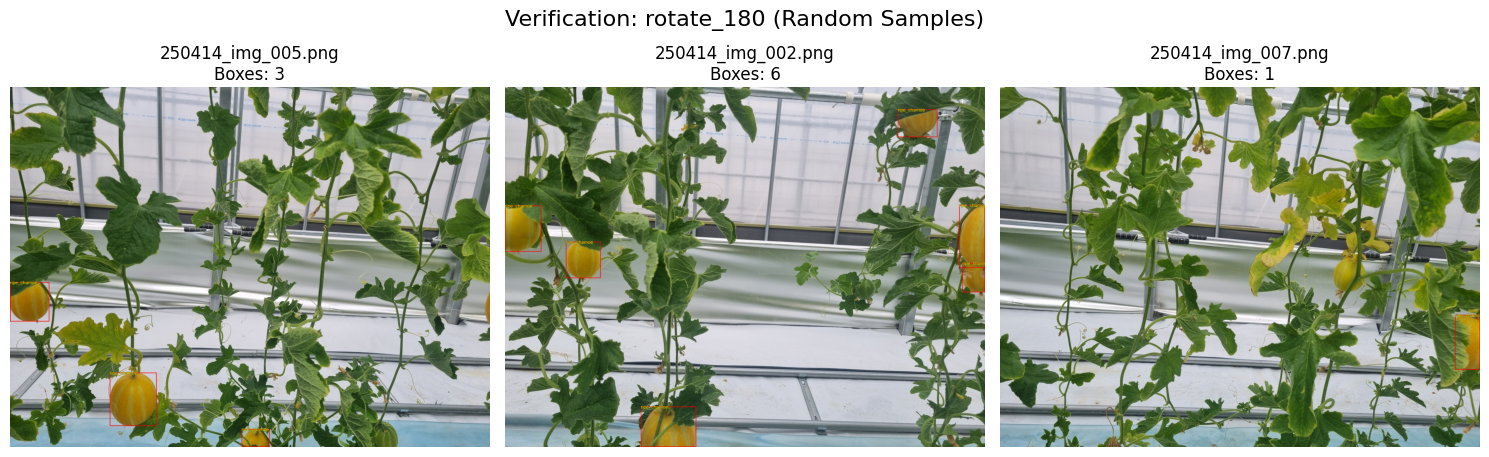

In [6]:
# verify_rotation.py

import os
import random
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def verify_rotation_results(root_folder_path, sample_count=3):
    # 1. 경로 설정
    xml_path = os.path.join(root_folder_path, 'annotations_final.xml')
    images_root = os.path.join(root_folder_path, 'images')
    
    target_folders = {
        'rotate_90': os.path.join(images_root, 'rotate_90'),
        'rotate_180': os.path.join(images_root, 'rotate_180')
    }

    # 2. XML 로드
    if not os.path.exists(xml_path):
        print(f"❌ 오류: '{xml_path}' 파일을 찾을 수 없습니다.")
        return

    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception as e:
        print(f"❌ XML 파싱 오류: {e}")
        return

    # 빠른 검색을 위한 매핑 (파일명 -> 이미지 태그)
    xml_map = {img.get('name'): img for img in root.findall('image')}

    # 3. 폴더별 샘플링 및 시각화
    for folder_name, folder_path in target_folders.items():
        if not os.path.exists(folder_path):
            print(f"⚠️ 경고: '{folder_name}' 폴더가 존재하지 않아 건너뜁니다.")
            continue

        # 이미지 파일 목록 가져오기
        all_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        
        if not all_files:
            print(f"⚠️ 경고: '{folder_name}' 폴더에 이미지가 없습니다.")
            continue

        # 랜덤 샘플링 (파일 개수가 sample_count보다 적으면 전체 선택)
        selected_files = random.sample(all_files, min(len(all_files), sample_count))
        
        print(f"\n🔍 [{folder_name}] 검증 시작 ({len(selected_files)}장)...")

        # 시각화를 위한 Plot 설정
        fig, axes = plt.subplots(1, len(selected_files), figsize=(5 * len(selected_files), 5))
        if len(selected_files) == 1: axes = [axes] # 1장일 경우 리스트로 변환
        
        fig.suptitle(f"Verification: {folder_name} (Random Samples)", fontsize=16)

        for idx, filename in enumerate(selected_files):
            full_img_path = os.path.join(folder_path, filename)
            
            # A. 이미지 로드
            try:
                img = Image.open(full_img_path)
                draw = ImageDraw.Draw(img)
            except Exception as e:
                print(f"   ❌ 이미지 로드 실패: {filename} / {e}")
                continue

            # B. XML 정보 매칭
            if filename in xml_map:
                img_xml = xml_map[filename]
                
                # Box 그리기
                boxes = img_xml.findall('box')
                for box in boxes:
                    label = box.get('label')
                    xtl = float(box.get('xtl'))
                    ytl = float(box.get('ytl'))
                    xbr = float(box.get('xbr'))
                    ybr = float(box.get('ybr'))
                    
                    # 사각형 그리기 (빨간색, 두께 3)
                    # PIL draw.rectangle은 [x0, y0, x1, y1] 순서
                    draw.rectangle([xtl, ytl, xbr, ybr], outline="red", width=5)
                    
                    # 라벨 텍스트 (선택 사항, 박스 왼쪽 상단에 표시)
                    # 폰트 로드 실패 시 기본 폰트 사용을 위한 예외처리
                    try:
                        # 리눅스/맥 등의 경우 경로가 다를 수 있음. 윈도우 기준 arial.ttf
                        font = ImageFont.truetype("arial.ttf", 40) 
                    except IOError:
                        font = ImageFont.load_default()
                        
                    draw.text((xtl, ytl - 20), label, fill="yellow", font=font, stroke_width=1, stroke_fill="black")
                
                title_text = f"{filename}\nBoxes: {len(boxes)}"
            else:
                title_text = f"{filename}\n(No XML Label Found)"

            # C. Matplotlib에 표시
            axes[idx].imshow(img)
            axes[idx].set_title(title_text)
            axes[idx].axis('off')

        plt.tight_layout()
        plt.show()

# --- 실행 ---
# dataset_cvat_cp 폴더 경로를 넣어주세요.
verify_rotation_results('./dataset_cvat_cp', sample_count=3)

In [7]:
# rename_simple.py

import os
import xml.etree.ElementTree as ET

def rename_dataset_simple(root_folder_path):
    # 1. 경로 설정
    # 이전 단계(회전 보정)의 결과물인 final 버전을 입력으로 사용
    xml_path = os.path.join(root_folder_path, 'annotations_final.xml')
    images_root = os.path.join(root_folder_path, 'images')
    
    # 최종 결과물 저장 경로
    output_xml_path = os.path.join(root_folder_path, 'annotations_renamed.xml')

    # 2. 파일 확인
    if not os.path.exists(xml_path):
        print(f"❌ 오류: '{xml_path}' 파일을 찾을 수 없습니다.")
        return
    if not os.path.exists(images_root):
        print(f"❌ 오류: '{images_root}' 폴더를 찾을 수 없습니다.")
        return

    print(f"📂 작업 시작: {root_folder_path}")
    print(f"   - 타겟 폴더: {images_root}")
    
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception as e:
        print(f"❌ XML 파싱 오류: {e}")
        return

    # 3. 이미지 태그 정렬 (Sorting)
    # 파일명(촬영 날짜/시간 등) 기준으로 오름차순 정렬하여 순서를 고정합니다.
    xml_images = root.findall('image')
    xml_images.sort(key=lambda x: x.get('name'))

    processed_count = 0
    error_count = 0
    
    print("🔄 정렬 및 파일명 변경 작업 시작...")

    # 4. 순회 및 이름 변경
    for idx, img_elem in enumerate(xml_images):
        old_filename = img_elem.get('name')
        file_ext = os.path.splitext(old_filename)[1] # 확장자(.jpg 등) 유지
        
        # 새로운 파일명 생성 (예: image0000.jpg)
        new_filename = f"image{idx:04d}{file_ext}"
        
        old_file_path = os.path.join(images_root, old_filename)
        new_file_path = os.path.join(images_root, new_filename)
        
        # 실제 파일이 존재하는지 확인
        if os.path.exists(old_file_path):
            try:
                # A. 파일 이름 변경 (Rename)
                # 이미 이름이 바뀌어 있을 경우(중복 실행 등)를 대비해 체크
                if old_filename != new_filename:
                    os.rename(old_file_path, new_file_path)
                
                # B. XML 정보 업데이트
                img_elem.set('name', new_filename) # 파일명 변경
                img_elem.set('id', str(idx))       # ID를 0부터 순차적으로 재부여

                processed_count += 1
                
            except OSError as e:
                print(f"   ❌ 파일명 변경 실패: {old_filename} -> {e}")
                error_count += 1
        else:
            # 만약 XML에는 있는데 폴더에 파일이 없다면? (이전 단계에서 정리했으므로 없어야 정상)
            print(f"   ⚠️ 경고: 파일을 찾을 수 없음 ({old_filename}) - XML만 수정됩니다.")
            # 파일은 없어도 XML 일관성을 위해 정보는 업데이트
            img_elem.set('name', new_filename)
            img_elem.set('id', str(idx))

    # 5. XML 내부 태그 순서 재배치 (깔끔하게 보이도록)
    # 기존 image 태그들을 다 떼어내고, 정렬된 리스트(xml_images) 순서대로 다시 붙임
    for img in root.findall('image'):
        root.remove(img)
    root.extend(xml_images)

    # 6. 저장
    tree.write(output_xml_path, encoding='utf-8', xml_declaration=True)

    # --- 결과 리포트 ---
    print("\n" + "=" * 50)
    print("✅ 작업 완료!")
    print(f"   - 총 처리된 파일 수 : {processed_count} 개")
    if error_count > 0:
        print(f"   - ❌ 에러 발생 : {error_count} 개")
    print(f"   - 파일명 형식       : image0000{file_ext} ~ image{processed_count-1:04d}{file_ext}")
    print(f"   - 저장된 XML 파일   : {output_xml_path}")
    print("=" * 50)

# --- 실행 ---
# dataset_cvat_cp 폴더 경로를 넣어주세요.
rename_dataset_simple('./dataset_cvat_cp')

📂 작업 시작: ./dataset_cvat_cp
   - 타겟 폴더: ./dataset_cvat_cp\images
🔄 정렬 및 파일명 변경 작업 시작...

✅ 작업 완료!
   - 총 처리된 파일 수 : 398 개
   - 파일명 형식       : image0000.png ~ image0397.png
   - 저장된 XML 파일   : ./dataset_cvat_cp\annotations_renamed.xml


📂 검증 시작: 총 398장의 이미지 중 4장 랜덤 샘플링


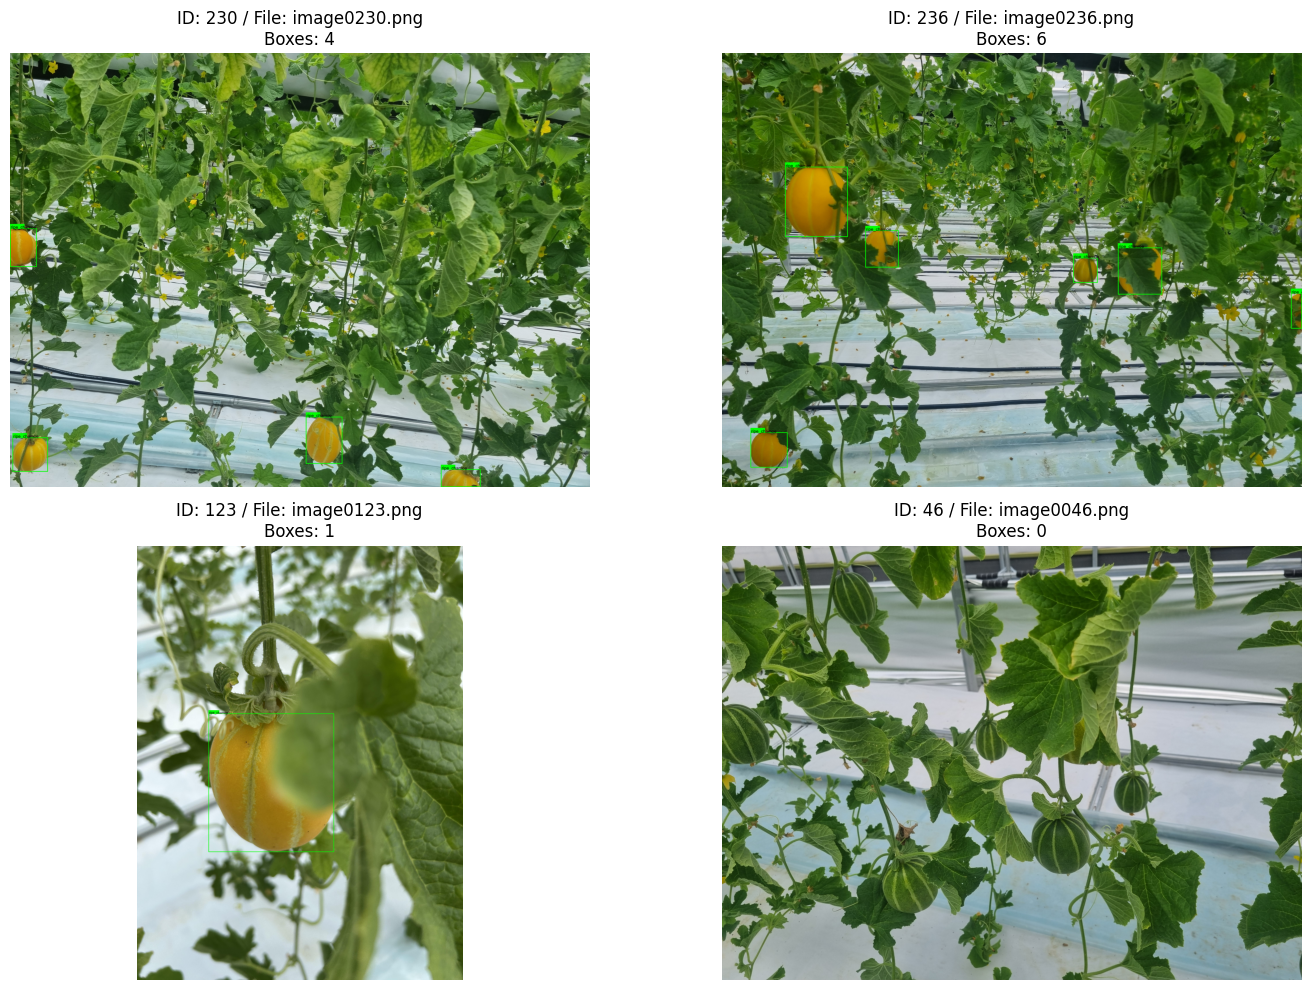

In [9]:
# verify_rename.py

import os
import random
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def verify_renamed_dataset(root_folder_path, sample_count=4):
    # 1. 경로 설정 (renamed 버전 사용)
    xml_path = os.path.join(root_folder_path, 'annotations_renamed.xml')
    images_root = os.path.join(root_folder_path, 'images')

    # 2. 파일 확인
    if not os.path.exists(xml_path):
        print(f"❌ 오류: '{xml_path}' 파일을 찾을 수 없습니다.")
        return

    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception as e:
        print(f"❌ XML 파싱 오류: {e}")
        return

    # 3. XML에서 이미지 목록 가져오기
    xml_images = root.findall('image')
    total_images = len(xml_images)
    
    if total_images == 0:
        print("⚠️ 경고: XML에 이미지 정보가 없습니다.")
        return

    print(f"📂 검증 시작: 총 {total_images}장의 이미지 중 {sample_count}장 랜덤 샘플링")

    # 4. 랜덤 샘플링
    selected_images = random.sample(xml_images, min(total_images, sample_count))

    # 5. 시각화 설정
    cols = 2
    rows = (len(selected_images) + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() if len(selected_images) > 1 else [axes]

    for idx, img_elem in enumerate(selected_images):
        filename = img_elem.get('name')
        img_id = img_elem.get('id')
        full_path = os.path.join(images_root, filename)

        ax = axes[idx]
        
        # A. 이미지 로드
        if os.path.exists(full_path):
            try:
                img = Image.open(full_path)
                draw = ImageDraw.Draw(img)
                
                # B. 박스 그리기
                boxes = img_elem.findall('box')
                for box in boxes:
                    label = box.get('label')
                    xtl = float(box.get('xtl'))
                    ytl = float(box.get('ytl'))
                    xbr = float(box.get('xbr'))
                    ybr = float(box.get('ybr'))

                    # 박스 (초록색, 두께 5)
                    draw.rectangle([xtl, ytl, xbr, ybr], outline="#00FF00", width=5)
                    
                    # 텍스트 설정
                    try:
                        font = ImageFont.truetype("arial.ttf", 30)
                    except IOError:
                        font = ImageFont.load_default()
                    
                    # 텍스트 배경 박스
                    text_w, text_h = 100, 30 # 대략적인 크기
                    draw.rectangle([xtl, ytl - text_h, xtl + text_w, ytl], fill="#00FF00")
                    draw.text((xtl + 5, ytl - 25), label, fill="black", font=font)

                ax.imshow(img)
                ax.set_title(f"ID: {img_id} / File: {filename}\nBoxes: {len(boxes)}", fontsize=12)
                ax.axis('off')

            except Exception as e:
                ax.text(0.5, 0.5, f"Error loading image:\n{e}", ha='center', va='center')
                ax.axis('off')
        else:
            ax.text(0.5, 0.5, f"File Not Found:\n{filename}", ha='center', va='center', color='red')
            ax.axis('off')

    # 남은 빈 서브플롯 끄기
    for i in range(len(selected_images), len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# --- 실행 ---
# dataset_cvat_cp 폴더 경로를 넣어주세요.
verify_renamed_dataset('./dataset_cvat_cp', sample_count=4)

In [12]:
# xml_to_yolo_unified.py

import os
import shutil
import xml.etree.ElementTree as ET
from tqdm import tqdm

def convert_to_yolo_no_split(root_folder_path, output_folder="dataset_yolo_all"):
    # 1. 경로 및 설정
    xml_path = os.path.join(root_folder_path, 'annotations.xml')
    images_root = os.path.join(root_folder_path, 'images')
    
    # 결과물 저장 경로 (images, labels 폴더 생성)
    out_img_dir = os.path.join(output_folder, 'images')
    out_lbl_dir = os.path.join(output_folder, 'labels')
    
    # 클래스 매핑 (0번부터 시작)
    class_map = {
        "ripe_chamoe": 0
    }

    # 2. 파일 확인
    if not os.path.exists(xml_path):
        print(f"❌ 오류: '{xml_path}' 파일을 찾을 수 없습니다.")
        return

    print(f"📂 변환 작업 시작: XML -> YOLO txt (분할 없음)")
    
    # 3. 폴더 생성 (기존에 있으면 삭제 후 재생성 - 클린 상태 유지)
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)
    os.makedirs(out_img_dir)
    os.makedirs(out_lbl_dir)

    # 4. XML 파싱
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception as e:
        print(f"❌ XML 파싱 오류: {e}")
        return

    xml_images = root.findall('image')
    print(f"   - 총 처리 대상 이미지: {len(xml_images)}장")

    # 5. 변환 루프
    for img_elem in tqdm(xml_images, desc="Converting"):
        filename = img_elem.get('name')
        
        # 이미지 크기 정보 (좌표 정규화에 필수)
        img_w = float(img_elem.get('width'))
        img_h = float(img_elem.get('height'))
        
        # 경로 설정
        src_img_path = os.path.join(images_root, filename)
        dst_img_path = os.path.join(out_img_dir, filename)
        
        # 라벨 파일명 (.jpg -> .txt)
        label_filename = os.path.splitext(filename)[0] + ".txt"
        dst_label_path = os.path.join(out_lbl_dir, label_filename)

        # A. 이미지 복사
        if os.path.exists(src_img_path):
            shutil.copy2(src_img_path, dst_img_path)
        else:
            print(f"⚠️ 경고: 이미지 파일 없음 - {filename}")
            continue

        # B. 라벨 파일 생성
        boxes = img_elem.findall('box')
        
        with open(dst_label_path, 'w') as f:
            for box in boxes:
                label_name = box.get('label')
                if label_name not in class_map:
                    continue

                class_id = class_map[label_name]
                
                # CVAT 좌표 (Top-Left, Bottom-Right)
                xtl = float(box.get('xtl'))
                ytl = float(box.get('ytl'))
                xbr = float(box.get('xbr'))
                ybr = float(box.get('ybr'))

                # YOLO 좌표 변환 공식 (Center X, Center Y, Width, Height) -> 0~1 정규화
                # 중심점 계산
                dw = 1.0 / img_w
                dh = 1.0 / img_h
                
                x_center = (xtl + xbr) / 2.0
                y_center = (ytl + ybr) / 2.0
                w = xbr - xtl
                h = ybr - ytl

                # 정규화 적용
                x_center *= dw
                y_center *= dh
                w *= dw
                h *= dh

                # 값 클램핑 (0.0 ~ 1.0 사이 강제 - 미세 오차 방지)
                x_center = max(0.0, min(1.0, x_center))
                y_center = max(0.0, min(1.0, y_center))
                w = max(0.0, min(1.0, w))
                h = max(0.0, min(1.0, h))

                # 텍스트 파일 쓰기: class_id x_center y_center width height
                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

    # 6. 클래스 정보 파일 생성 (참고용)
    with open(os.path.join(output_folder, 'classes.txt'), 'w') as f:
        for name, idx in class_map.items():
            f.write(f"{name}\n")

    print("\n" + "=" * 50)
    print("🎉 통합 데이터셋 변환 완료!")
    print(f"   - 저장 위치: {output_folder}")
    print(f"     ├─ images/: 이미지 {len(xml_images)}장")
    print(f"     └─ labels/: 라벨 텍스트 {len(xml_images)}개")
    print("=" * 50)

# --- 실행 ---
# pip install tqdm 필요
convert_to_yolo_no_split('./dataset_cvat', output_folder='./dataset_yolo_all')

📂 변환 작업 시작: XML -> YOLO txt (분할 없음)
   - 총 처리 대상 이미지: 398장


Converting: 100%|██████████| 398/398 [00:06<00:00, 60.09it/s] 


🎉 통합 데이터셋 변환 완료!
   - 저장 위치: ./dataset_yolo_all
     ├─ images/: 이미지 398장
     └─ labels/: 라벨 텍스트 398개


In [15]:
# split_optimized.py

import os
import shutil
import random
from tqdm import tqdm

def split_optimized(
    source_folder="dataset_yolo_all", 
    output_folder="dataset_yolo_optimized", 
    ratios=(0.7, 0.15, 0.15),
    num_trials=50000  # 최적의 조합을 찾기 위한 시도 횟수
):
    # 1. 경로 설정
    src_images_dir = os.path.join(source_folder, "images")
    src_labels_dir = os.path.join(source_folder, "labels")
    
    if not os.path.exists(src_images_dir) or not os.path.exists(src_labels_dir):
        print("❌ 오류: 소스 데이터 폴더 구조가 올바르지 않습니다.")
        return

    # 2. 데이터 스캔 (파일명과 객체 수 파악)
    print("📊 데이터 분석 중...")
    data_list = [] # [(filename, obj_count), ...]
    
    label_files = [f for f in os.listdir(src_labels_dir) if f.endswith('.txt')]
    
    for label_file in label_files:
        file_id = os.path.splitext(label_file)[0]
        label_path = os.path.join(src_labels_dir, label_file)
        
        # 객체 수 카운트
        with open(label_path, 'r') as f:
            obj_count = len(f.readlines())
            
        # 이미지 확장자 찾기
        img_ext = None
        for ext in ['.jpg', '.png', '.jpeg', '.JPG']:
            if os.path.exists(os.path.join(src_images_dir, file_id + ext)):
                img_ext = ext
                break
        
        if img_ext:
            data_list.append({
                'id': file_id,
                'ext': img_ext,
                'obj_count': obj_count
            })

    total_images = len(data_list)
    total_objects = sum(d['obj_count'] for d in data_list)
    
    print(f"   - 총 이미지: {total_images}장")
    print(f"   - 총 객체수: {total_objects}개")

    # 3. 목표 이미지 개수 계산 (Hard Constraint)
    n_train = int(total_images * ratios[0])
    n_val = int(total_images * ratios[1])
    n_test = total_images - n_train - n_val # 나머지는 테스트 (개수 보정)

    print(f"   - 목표 분할(장): Train({n_train}) / Val({n_val}) / Test({n_test})")

    # 4. 최적화 루프 (Monte Carlo Simulation)
    print(f"🔄 최적의 분할 조합 탐색 중 ({num_trials}회 시도)...")
    
    best_score = float('inf')
    best_split = None
    best_stats = None

    # 진행바는 1초마다 갱신 (속도 저하 방지)
    for _ in tqdm(range(num_trials), mininterval=1.0):
        random.shuffle(data_list)
        
        # 리스트 슬라이싱으로 분할
        train_set = data_list[:n_train]
        val_set = data_list[n_train : n_train + n_val]
        test_set = data_list[n_train + n_val :]
        
        # 객체 수 합계 계산
        t_objs = sum(d['obj_count'] for d in train_set)
        v_objs = sum(d['obj_count'] for d in val_set)
        test_objs = sum(d['obj_count'] for d in test_set)
        
        # 비율 계산
        t_ratio = t_objs / total_objects if total_objects > 0 else 0
        v_ratio = v_objs / total_objects if total_objects > 0 else 0
        test_ratio = test_objs / total_objects if total_objects > 0 else 0
        
        # 손실 함수 (Loss Function): 목표 비율과의 오차 합계
        # MSE와 유사하게 계산 (오차 절대값의 합)
        error = abs(t_ratio - ratios[0]) + abs(v_ratio - ratios[1]) + abs(test_ratio - ratios[2])
        
        if error < best_score:
            best_score = error
            best_split = {'train': train_set, 'val': val_set, 'test': test_set}
            best_stats = {
                'train': {'imgs': len(train_set), 'objs': t_objs, 'ratio': t_ratio},
                'val': {'imgs': len(val_set), 'objs': v_objs, 'ratio': v_ratio},
                'test': {'imgs': len(test_set), 'objs': test_objs, 'ratio': test_ratio}
            }
            
            # 만약 오차가 0.1% 미만이면 조기 종료 (충분히 좋음)
            if error < 0.001:
                break

    # 5. 결과 검증 및 파일 복사
    print("\n✨ 최적 조합 발견!")
    print("-" * 65)
    print(f"{'Split':<8} | {'Img Target':<10} | {'Img Actual':<10} | {'Obj Ratio':<10} | {'Obj Error':<10}")
    print("-" * 65)
    
    for split in ['train', 'val', 'test']:
        stat = best_stats[split]
        target_ratio = ratios[0] if split == 'train' else (ratios[1] if split == 'val' else ratios[2])
        target_img = n_train if split == 'train' else (n_val if split == 'val' else n_test)
        
        # 오차율 (퍼센트 포인트)
        diff = (stat['ratio'] - target_ratio) * 100
        print(f"{split.upper():<8} | {target_img:<10} | {stat['imgs']:<10} | {stat['ratio']*100:.2f}%     | {diff:+.2f}%")
    print("-" * 65)

    # 파일 복사 시작
    print("🚀 파일 복사 시작...")
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)
    
    for split_name, dataset in best_split.items():
        os.makedirs(os.path.join(output_folder, 'images', split_name), exist_ok=True)
        os.makedirs(os.path.join(output_folder, 'labels', split_name), exist_ok=True)
        
        for item in dataset:
            src_img = os.path.join(src_images_dir, item['id'] + item['ext'])
            src_lbl = os.path.join(src_labels_dir, item['id'] + ".txt")
            
            dst_img = os.path.join(output_folder, 'images', split_name, item['id'] + item['ext'])
            dst_lbl = os.path.join(output_folder, 'labels', split_name, item['id'] + ".txt")
            
            shutil.copy2(src_img, dst_img)
            shutil.copy2(src_lbl, dst_lbl)

    # 6. data.yaml 생성
    names_list = "['ripe_chamoe']"
    yaml_content = f"""train: images/train
val: images/val
test: images/test

nc: 1
names: {names_list}
"""
    with open(os.path.join(output_folder, 'data.yaml'), 'w') as f:
        f.write(yaml_content)

    print(f"✅ 모든 작업 완료! 저장 위치: {output_folder}")

# --- 실행 ---
split_optimized(
    'dataset_yolo', 
    'dataset_yolo_split', 
    ratios=(0.7, 0.15, 0.15),
    num_trials=50000  # 5만 번 정도 섞어보면 거의 최적값을 찾습니다.
)

📊 데이터 분석 중...
   - 총 이미지: 398장
   - 총 객체수: 978개
   - 목표 분할(장): Train(278) / Val(59) / Test(61)
🔄 최적의 분할 조합 탐색 중 (50000회 시도)...


100%|██████████| 50000/50000 [00:05<00:00, 9133.61it/s]



✨ 최적 조합 발견!
-----------------------------------------------------------------
Split    | Img Target | Img Actual | Obj Ratio  | Obj Error 
-----------------------------------------------------------------
TRAIN    | 278        | 278        | 69.94%     | -0.06%
VAL      | 59         | 59         | 15.03%     | +0.03%
TEST     | 61         | 61         | 15.03%     | +0.03%
-----------------------------------------------------------------
🚀 파일 복사 시작...
✅ 모든 작업 완료! 저장 위치: dataset_yolo_split


# 드론 데이터셋 필터링

In [14]:
# clean_dataset.py

import os
import xml.etree.ElementTree as ET

def clean_unlabeled_images(xml_path, image_folder, dry_run=True):
    """
    CVAT xml 파일을 읽어 라벨링(box) 정보가 없는 이미지를 폴더에서 삭제합니다.
    
    :param xml_path: annotations.xml 파일 경로
    :param image_folder: 이미지가 들어있는 폴더 경로
    :param dry_run: True일 경우 실제 삭제하지 않고 삭제 대상만 출력
    """
    
    # 1. XML 파일 파싱
    if not os.path.exists(xml_path):
        print(f"Error: XML 파일을 찾을 수 없습니다: {xml_path}")
        return

    tree = ET.parse(xml_path)
    root = tree.getroot()

    # 2. 라벨링이 되어 있는 이미지 파일명 수집 (White List)
    labeled_files = set()
    
    # CVAT for images 1.1 형식은 <image> 태그 아래에 <box>가 있음
    for image in root.findall('image'):
        file_name = image.get('name')
        
        # box 태그가 하나라도 있는지 확인
        boxes = image.findall('box')
        
        if len(boxes) > 0:
            labeled_files.add(file_name)

    print(f"XML 분석 완료: 총 {len(root.findall('image'))}개 중 {len(labeled_files)}개의 이미지가 라벨링 되어 있습니다.")

    # 3. 폴더 내 이미지 순회하며 삭제 대상 식별
    if not os.path.exists(image_folder):
        print(f"Error: 이미지 폴더를 찾을 수 없습니다: {image_folder}")
        return

    all_files_in_dir = os.listdir(image_folder)
    deleted_count = 0
    
    print("\n--- 작업 시작 ---")
    if dry_run:
        print("[주의] Dry Run 모드입니다. 파일이 실제로 삭제되지 않습니다.")
    
    for filename in all_files_in_dir:
        # 이미지 확장자인지 확인 (필요시 확장자 추가 가능)
        if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            
            # 라벨링된 파일 목록에 없으면 삭제 대상
            if filename not in labeled_files:
                file_path = os.path.join(image_folder, filename)
                
                if dry_run:
                    print(f"[삭제 예정] {filename} (라벨 없음)")
                else:
                    try:
                        os.remove(file_path)
                        print(f"[삭제 완료] {filename}")
                        deleted_count += 1
                    except Exception as e:
                        print(f"[삭제 실패] {filename}: {e}")

    # 4. 결과 리포트
    if dry_run:
        print(f"\n[Dry Run 결과] 총 {len(all_files_in_dir) - len(labeled_files)}개의 파일이 삭제될 예정입니다.")
        print("실제로 삭제하려면 코드 하단의 dry_run=True를 False로 변경하세요.")
    else:
        print(f"\n[작업 완료] 총 {deleted_count}개의 라벨 없는 이미지를 삭제했습니다.")

# ==========================================
# 사용 방법
# ==========================================

BASE_PATH = "C:/Users/henho/OneDrive/Desktop/MCVS_for_ChamDog/mcvs_for_chamdog/lab/dataset/1_drone_dataset"
# 1. annotations.xml 파일의 경로를 입력하세요.
xml_file_path = f'{BASE_PATH}/annotations.xml' 

# 2. 이미지가 모여있는 폴더의 경로를 입력하세요.
target_image_folder = f'{BASE_PATH}/images' 

# 3. 테스트(Dry Run)를 하려면 True, 실제 삭제하려면 False로 설정하세요.
# 처음엔 True로 실행해서 목록을 확인하는 것을 강력 추천해!
is_dry_run = False 

clean_unlabeled_images(xml_file_path, target_image_folder, is_dry_run)

XML 분석 완료: 총 674개 중 250개의 이미지가 라벨링 되어 있습니다.

--- 작업 시작 ---
[삭제 완료] 20250404_video1_000.jpg
[삭제 완료] 20250404_video2_111.jpg
[삭제 완료] 20250404_video3_112.jpg
[삭제 완료] 20250404_video3_114.jpg
[삭제 완료] 20250404_video4_062.jpg
[삭제 완료] 20250404_video4_063.jpg
[삭제 완료] 20250404_video5_067.jpg
[삭제 완료] 20250404_video5_125.jpg
[삭제 완료] 20250404_video5_130.jpg
[삭제 완료] 20250404_video6_095.jpg
[삭제 완료] 20250414_video1_010.jpg
[삭제 완료] 20250414_video1_011.jpg
[삭제 완료] 20250414_video4_003.jpg
[삭제 완료] 20250414_video4_009.jpg
[삭제 완료] 20250414_video4_108.jpg
[삭제 완료] 20250414_video4_111.jpg
[삭제 완료] 20250414_video5_000.jpg
[삭제 완료] 20250414_video5_004.jpg
[삭제 완료] 20250414_video5_014.jpg
[삭제 완료] 20250414_video5_020.jpg
[삭제 완료] 20250414_video5_024.jpg
[삭제 완료] 20250414_video5_026.jpg
[삭제 완료] 20250414_video5_028.jpg
[삭제 완료] 20250414_video5_030.jpg
[삭제 완료] 20250414_video5_032.jpg
[삭제 완료] 20250414_video5_040.jpg
[삭제 완료] 20250414_video5_046.jpg
[삭제 완료] 20250414_video5_060.jpg
[삭제 완료] 20250414_video5_064.jpg
[삭제 완료] 20250

In [15]:
# clean_xml.py

import os
import xml.etree.ElementTree as ET

def clean_and_update_metadata(root_folder_path):
    # 1. 파일 경로 설정
    xml_path = os.path.join(root_folder_path, 'annotations.xml')
    images_folder = os.path.join(root_folder_path, 'images')
    output_xml_path = os.path.join(root_folder_path, 'annotations_cleaned.xml')

    # 2. 파일 존재 확인
    if not os.path.exists(xml_path):
        print(f"❌ 오류: '{xml_path}' 파일을 찾을 수 없습니다.")
        return
    if not os.path.exists(images_folder):
        print(f"❌ 오류: '{images_folder}' 폴더를 찾을 수 없습니다.")
        return

    print(f"📂 작업 시작: {root_folder_path}")
    
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except ET.ParseError as e:
        print(f"❌ XML 파싱 오류: {e}")
        return

    # 3. 이미지 태그 순회 및 정리 (유효 이미지 선별)
    xml_images = root.findall('image')
    
    new_id = 0          # 새로 부여할 ID (0부터 시작)
    removed_count = 0   # 삭제된 이미지 수
    kept_count = 0      # 유지된 이미지 수

    for image in xml_images:
        filename = image.get('name')
        full_image_path = os.path.join(images_folder, filename)

        if os.path.exists(full_image_path):
            # 파일이 존재하면 ID 재할당 (0, 1, 2...)
            image.set('id', str(new_id))
            new_id += 1
            kept_count += 1
        else:
            # 파일이 없으면 XML에서 제거
            root.remove(image)
            removed_count += 1

    # 유효한 이미지가 하나도 없으면 중단
    if kept_count == 0:
        print("❌ 오류: 유효한 이미지가 하나도 남지 않았습니다.")
        return

    # 4. 메타데이터(Meta) 업데이트
    # (1) <size>: 전체 이미지 개수
    size_tag = root.find('.//meta/task/size')
    if size_tag is not None:
        print(f"   ℹ️ [size] 업데이트: {size_tag.text} -> {kept_count}")
        size_tag.text = str(kept_count)

    # (2) <stop_frame>: 마지막 인덱스 (개수 - 1)
    stop_frame_tag = root.find('.//meta/task/stop_frame')
    if stop_frame_tag is not None:
        new_stop_frame = kept_count - 1
        print(f"   ℹ️ [stop_frame] 업데이트: {stop_frame_tag.text} -> {new_stop_frame}")
        stop_frame_tag.text = str(new_stop_frame)

    # (3) <segments><segment><stop>: 세그먼트 종료 인덱스 (개수 - 1)
    # 보통 CVAT XML에는 하나의 segment만 있는 경우가 많지만, 혹시 모르니 모두 순회
    segments = root.findall('.//meta/task/segments/segment')
    for seg in segments:
        stop_tag = seg.find('stop')
        if stop_tag is not None:
            new_stop = kept_count - 1
            print(f"   ℹ️ [segment/stop] 업데이트: {stop_tag.text} -> {new_stop}")
            stop_tag.text = str(new_stop)

    # 5. 저장
    tree.write(output_xml_path, encoding='utf-8', xml_declaration=True)

    # --- 결과 리포트 ---
    print("\n" + "=" * 40)
    print("✅ 메타데이터 및 인덱스 정리 완료!")
    print(f"   - 기존 이미지 수 : {len(xml_images)} 개")
    print(f"   - 삭제된 이미지  : {removed_count} 개")
    print(f"   - 최종 이미지 수 : {kept_count} 개")
    print(f"   - 최종 ID 범위   : 0 ~ {kept_count - 1}")
    print(f"   - 저장 파일명    : {output_xml_path}")
    print("=" * 40)

# --- 실행 ---
# 폴더 경로를 본인 환경에 맞게 수정해주세요.
clean_and_update_metadata(BASE_PATH)

📂 작업 시작: C:/Users/henho/OneDrive/Desktop/MCVS_for_ChamDog/mcvs_for_chamdog/lab/dataset/1_drone_dataset
   ℹ️ [size] 업데이트: 682 -> 250
   ℹ️ [stop_frame] 업데이트: 681 -> 249
   ℹ️ [segment/stop] 업데이트: 681 -> 249

✅ 메타데이터 및 인덱스 정리 완료!
   - 기존 이미지 수 : 674 개
   - 삭제된 이미지  : 424 개
   - 최종 이미지 수 : 250 개
   - 최종 ID 범위   : 0 ~ 249
   - 저장 파일명    : C:/Users/henho/OneDrive/Desktop/MCVS_for_ChamDog/mcvs_for_chamdog/lab/dataset/1_drone_dataset\annotations_cleaned.xml


In [16]:
# rename_simple.py

import os
import xml.etree.ElementTree as ET

def rename_dataset_simple(root_folder_path):
    # 1. 경로 설정
    # 이전 단계(회전 보정)의 결과물인 final 버전을 입력으로 사용
    xml_path = os.path.join(root_folder_path, 'annotations_cleaned.xml')
    images_root = os.path.join(root_folder_path, 'images')
    
    # 최종 결과물 저장 경로
    output_xml_path = os.path.join(root_folder_path, 'annotations_renamed.xml')

    # 2. 파일 확인
    if not os.path.exists(xml_path):
        print(f"❌ 오류: '{xml_path}' 파일을 찾을 수 없습니다.")
        return
    if not os.path.exists(images_root):
        print(f"❌ 오류: '{images_root}' 폴더를 찾을 수 없습니다.")
        return

    print(f"📂 작업 시작: {root_folder_path}")
    print(f"   - 타겟 폴더: {images_root}")
    
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception as e:
        print(f"❌ XML 파싱 오류: {e}")
        return

    # 3. 이미지 태그 정렬 (Sorting)
    # 파일명(촬영 날짜/시간 등) 기준으로 오름차순 정렬하여 순서를 고정합니다.
    xml_images = root.findall('image')
    xml_images.sort(key=lambda x: x.get('name'))

    processed_count = 0
    error_count = 0
    
    print("🔄 정렬 및 파일명 변경 작업 시작...")

    # 4. 순회 및 이름 변경
    for idx, img_elem in enumerate(xml_images):
        old_filename = img_elem.get('name')
        file_ext = os.path.splitext(old_filename)[1] # 확장자(.jpg 등) 유지
        
        # 새로운 파일명 생성 (예: image0000.jpg)
        new_filename = f"drone_image{idx:03d}{file_ext}"
        
        old_file_path = os.path.join(images_root, old_filename)
        new_file_path = os.path.join(images_root, new_filename)
        
        # 실제 파일이 존재하는지 확인
        if os.path.exists(old_file_path):
            try:
                # A. 파일 이름 변경 (Rename)
                # 이미 이름이 바뀌어 있을 경우(중복 실행 등)를 대비해 체크
                if old_filename != new_filename:
                    os.rename(old_file_path, new_file_path)
                
                # B. XML 정보 업데이트
                img_elem.set('name', new_filename) # 파일명 변경
                img_elem.set('id', str(idx))       # ID를 0부터 순차적으로 재부여

                processed_count += 1
                
            except OSError as e:
                print(f"   ❌ 파일명 변경 실패: {old_filename} -> {e}")
                error_count += 1
        else:
            # 만약 XML에는 있는데 폴더에 파일이 없다면? (이전 단계에서 정리했으므로 없어야 정상)
            print(f"   ⚠️ 경고: 파일을 찾을 수 없음 ({old_filename}) - XML만 수정됩니다.")
            # 파일은 없어도 XML 일관성을 위해 정보는 업데이트
            img_elem.set('name', new_filename)
            img_elem.set('id', str(idx))

    # 5. XML 내부 태그 순서 재배치 (깔끔하게 보이도록)
    # 기존 image 태그들을 다 떼어내고, 정렬된 리스트(xml_images) 순서대로 다시 붙임
    for img in root.findall('image'):
        root.remove(img)
    root.extend(xml_images)

    # 6. 저장
    tree.write(output_xml_path, encoding='utf-8', xml_declaration=True)

    # --- 결과 리포트 ---
    print("\n" + "=" * 50)
    print("✅ 작업 완료!")
    print(f"   - 총 처리된 파일 수 : {processed_count} 개")
    if error_count > 0:
        print(f"   - ❌ 에러 발생 : {error_count} 개")
    print(f"   - 파일명 형식       : image0000{file_ext} ~ image{processed_count-1:04d}{file_ext}")
    print(f"   - 저장된 XML 파일   : {output_xml_path}")
    print("=" * 50)

# --- 실행 ---
# dataset_cvat_cp 폴더 경로를 넣어주세요.

BASE_PATH = "C:/Users/henho/OneDrive/Desktop/MCVS_for_ChamDog/mcvs_for_chamdog/lab/dataset/1_drone_dataset"
rename_dataset_simple(BASE_PATH)

📂 작업 시작: C:/Users/henho/OneDrive/Desktop/MCVS_for_ChamDog/mcvs_for_chamdog/lab/dataset/1_drone_dataset
   - 타겟 폴더: C:/Users/henho/OneDrive/Desktop/MCVS_for_ChamDog/mcvs_for_chamdog/lab/dataset/1_drone_dataset\images
🔄 정렬 및 파일명 변경 작업 시작...

✅ 작업 완료!
   - 총 처리된 파일 수 : 250 개
   - 파일명 형식       : image0000.jpg ~ image0249.jpg
   - 저장된 XML 파일   : C:/Users/henho/OneDrive/Desktop/MCVS_for_ChamDog/mcvs_for_chamdog/lab/dataset/1_drone_dataset\annotations_renamed.xml


In [1]:
# xml_to_yolo_unified.py

import os
import shutil
import xml.etree.ElementTree as ET
from tqdm import tqdm

def convert_to_yolo_no_split(root_folder_path, output_folder="dataset_yolo_all"):
    # 1. 경로 및 설정
    xml_path = os.path.join(root_folder_path, 'annotations.xml')
    images_root = os.path.join(root_folder_path, 'images')
    
    # 결과물 저장 경로 (images, labels 폴더 생성)
    out_img_dir = os.path.join(output_folder, 'images')
    out_lbl_dir = os.path.join(output_folder, 'labels')
    
    # 클래스 매핑 (0번부터 시작)
    class_map = {
        "ripe_chamoe": 0
    }

    # 2. 파일 확인
    if not os.path.exists(xml_path):
        print(f"❌ 오류: '{xml_path}' 파일을 찾을 수 없습니다.")
        return

    print(f"📂 변환 작업 시작: XML -> YOLO txt (분할 없음)")
    
    # 3. 폴더 생성 (기존에 있으면 삭제 후 재생성 - 클린 상태 유지)
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)
    os.makedirs(out_img_dir)
    os.makedirs(out_lbl_dir)

    # 4. XML 파싱
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception as e:
        print(f"❌ XML 파싱 오류: {e}")
        return

    xml_images = root.findall('image')
    print(f"   - 총 처리 대상 이미지: {len(xml_images)}장")

    # 5. 변환 루프
    for img_elem in tqdm(xml_images, desc="Converting"):
        filename = img_elem.get('name')
        
        # 이미지 크기 정보 (좌표 정규화에 필수)
        img_w = float(img_elem.get('width'))
        img_h = float(img_elem.get('height'))
        
        # 경로 설정
        src_img_path = os.path.join(images_root, filename)
        dst_img_path = os.path.join(out_img_dir, filename)
        
        # 라벨 파일명 (.jpg -> .txt)
        label_filename = os.path.splitext(filename)[0] + ".txt"
        dst_label_path = os.path.join(out_lbl_dir, label_filename)

        # A. 이미지 복사
        if os.path.exists(src_img_path):
            shutil.copy2(src_img_path, dst_img_path)
        else:
            print(f"⚠️ 경고: 이미지 파일 없음 - {filename}")
            continue

        # B. 라벨 파일 생성
        boxes = img_elem.findall('box')
        
        with open(dst_label_path, 'w') as f:
            for box in boxes:
                label_name = box.get('label')
                if label_name not in class_map:
                    continue

                class_id = class_map[label_name]
                
                # CVAT 좌표 (Top-Left, Bottom-Right)
                xtl = float(box.get('xtl'))
                ytl = float(box.get('ytl'))
                xbr = float(box.get('xbr'))
                ybr = float(box.get('ybr'))

                # YOLO 좌표 변환 공식 (Center X, Center Y, Width, Height) -> 0~1 정규화
                # 중심점 계산
                dw = 1.0 / img_w
                dh = 1.0 / img_h
                
                x_center = (xtl + xbr) / 2.0
                y_center = (ytl + ybr) / 2.0
                w = xbr - xtl
                h = ybr - ytl

                # 정규화 적용
                x_center *= dw
                y_center *= dh
                w *= dw
                h *= dh

                # 값 클램핑 (0.0 ~ 1.0 사이 강제 - 미세 오차 방지)
                x_center = max(0.0, min(1.0, x_center))
                y_center = max(0.0, min(1.0, y_center))
                w = max(0.0, min(1.0, w))
                h = max(0.0, min(1.0, h))

                # 텍스트 파일 쓰기: class_id x_center y_center width height
                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

    # 6. 클래스 정보 파일 생성 (참고용)
    with open(os.path.join(output_folder, 'classes.txt'), 'w') as f:
        for name, idx in class_map.items():
            f.write(f"{name}\n")

    print("\n" + "=" * 50)
    print("🎉 통합 데이터셋 변환 완료!")
    print(f"   - 저장 위치: {output_folder}")
    print(f"     ├─ images/: 이미지 {len(xml_images)}장")
    print(f"     └─ labels/: 라벨 텍스트 {len(xml_images)}개")
    print("=" * 50)

# --- 실행 ---
# pip install tqdm 필요
convert_to_yolo_no_split("C:/Users/henho/OneDrive/Desktop/EDL_test/1_drone_dataset",
                         output_folder="C:/Users/henho/OneDrive/Desktop/EDL_test/dataset_yolo_all")

📂 변환 작업 시작: XML -> YOLO txt (분할 없음)
   - 총 처리 대상 이미지: 203장


Converting: 100%|██████████| 203/203 [00:02<00:00, 71.51it/s]


🎉 통합 데이터셋 변환 완료!
   - 저장 위치: C:/Users/henho/OneDrive/Desktop/EDL_test/dataset_yolo_all
     ├─ images/: 이미지 203장
     └─ labels/: 라벨 텍스트 203개


In [2]:
# split_optimized.py

import os
import shutil
import random
from tqdm import tqdm

def split_optimized(
    source_folder="dataset_yolo_all", 
    output_folder="dataset_yolo_optimized", 
    ratios=(0.7, 0.15, 0.15),
    num_trials=50000  # 최적의 조합을 찾기 위한 시도 횟수
):
    # 1. 경로 설정
    src_images_dir = os.path.join(source_folder, "images")
    src_labels_dir = os.path.join(source_folder, "labels")
    
    if not os.path.exists(src_images_dir) or not os.path.exists(src_labels_dir):
        print("❌ 오류: 소스 데이터 폴더 구조가 올바르지 않습니다.")
        return

    # 2. 데이터 스캔 (파일명과 객체 수 파악)
    print("📊 데이터 분석 중...")
    data_list = [] # [(filename, obj_count), ...]
    
    label_files = [f for f in os.listdir(src_labels_dir) if f.endswith('.txt')]
    
    for label_file in label_files:
        file_id = os.path.splitext(label_file)[0]
        label_path = os.path.join(src_labels_dir, label_file)
        
        # 객체 수 카운트
        with open(label_path, 'r') as f:
            obj_count = len(f.readlines())
            
        # 이미지 확장자 찾기
        img_ext = None
        for ext in ['.jpg', '.png', '.jpeg', '.JPG']:
            if os.path.exists(os.path.join(src_images_dir, file_id + ext)):
                img_ext = ext
                break
        
        if img_ext:
            data_list.append({
                'id': file_id,
                'ext': img_ext,
                'obj_count': obj_count
            })

    total_images = len(data_list)
    total_objects = sum(d['obj_count'] for d in data_list)
    
    print(f"   - 총 이미지: {total_images}장")
    print(f"   - 총 객체수: {total_objects}개")

    # 3. 목표 이미지 개수 계산 (Hard Constraint)
    n_train = int(total_images * ratios[0])
    n_val = int(total_images * ratios[1])
    n_test = total_images - n_train - n_val # 나머지는 테스트 (개수 보정)

    print(f"   - 목표 분할(장): Train({n_train}) / Val({n_val}) / Test({n_test})")

    # 4. 최적화 루프 (Monte Carlo Simulation)
    print(f"🔄 최적의 분할 조합 탐색 중 ({num_trials}회 시도)...")
    
    best_score = float('inf')
    best_split = None
    best_stats = None

    # 진행바는 1초마다 갱신 (속도 저하 방지)
    for _ in tqdm(range(num_trials), mininterval=1.0):
        random.shuffle(data_list)
        
        # 리스트 슬라이싱으로 분할
        train_set = data_list[:n_train]
        val_set = data_list[n_train : n_train + n_val]
        test_set = data_list[n_train + n_val :]
        
        # 객체 수 합계 계산
        t_objs = sum(d['obj_count'] for d in train_set)
        v_objs = sum(d['obj_count'] for d in val_set)
        test_objs = sum(d['obj_count'] for d in test_set)
        
        # 비율 계산
        t_ratio = t_objs / total_objects if total_objects > 0 else 0
        v_ratio = v_objs / total_objects if total_objects > 0 else 0
        test_ratio = test_objs / total_objects if total_objects > 0 else 0
        
        # 손실 함수 (Loss Function): 목표 비율과의 오차 합계
        # MSE와 유사하게 계산 (오차 절대값의 합)
        error = abs(t_ratio - ratios[0]) + abs(v_ratio - ratios[1]) + abs(test_ratio - ratios[2])
        
        if error < best_score:
            best_score = error
            best_split = {'train': train_set, 'val': val_set, 'test': test_set}
            best_stats = {
                'train': {'imgs': len(train_set), 'objs': t_objs, 'ratio': t_ratio},
                'val': {'imgs': len(val_set), 'objs': v_objs, 'ratio': v_ratio},
                'test': {'imgs': len(test_set), 'objs': test_objs, 'ratio': test_ratio}
            }
            
            # 만약 오차가 0.1% 미만이면 조기 종료 (충분히 좋음)
            if error < 0.001:
                break

    # 5. 결과 검증 및 파일 복사
    print("\n✨ 최적 조합 발견!")
    print("-" * 65)
    print(f"{'Split':<8} | {'Img Target':<10} | {'Img Actual':<10} | {'Obj Ratio':<10} | {'Obj Error':<10}")
    print("-" * 65)
    
    for split in ['train', 'val', 'test']:
        stat = best_stats[split]
        target_ratio = ratios[0] if split == 'train' else (ratios[1] if split == 'val' else ratios[2])
        target_img = n_train if split == 'train' else (n_val if split == 'val' else n_test)
        
        # 오차율 (퍼센트 포인트)
        diff = (stat['ratio'] - target_ratio) * 100
        print(f"{split.upper():<8} | {target_img:<10} | {stat['imgs']:<10} | {stat['ratio']*100:.2f}%     | {diff:+.2f}%")
    print("-" * 65)

    # 파일 복사 시작
    print("🚀 파일 복사 시작...")
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)
    
    for split_name, dataset in best_split.items():
        os.makedirs(os.path.join(output_folder, 'images', split_name), exist_ok=True)
        os.makedirs(os.path.join(output_folder, 'labels', split_name), exist_ok=True)
        
        for item in dataset:
            src_img = os.path.join(src_images_dir, item['id'] + item['ext'])
            src_lbl = os.path.join(src_labels_dir, item['id'] + ".txt")
            
            dst_img = os.path.join(output_folder, 'images', split_name, item['id'] + item['ext'])
            dst_lbl = os.path.join(output_folder, 'labels', split_name, item['id'] + ".txt")
            
            shutil.copy2(src_img, dst_img)
            shutil.copy2(src_lbl, dst_lbl)

    # 6. data.yaml 생성
    names_list = "['ripe_chamoe']"
    yaml_content = f"""train: images/train
val: images/val
test: images/test

nc: 1
names: {names_list}
"""
    with open(os.path.join(output_folder, 'data.yaml'), 'w') as f:
        f.write(yaml_content)

    print(f"✅ 모든 작업 완료! 저장 위치: {output_folder}")

# --- 실행 ---
split_optimized(
    "C:/Users/henho/OneDrive/Desktop/EDL_test/dataset_yolo_all", 
    "C:/Users/henho/OneDrive/Desktop/EDL_test/dataset_yolo_split", 
    ratios=(0.7, 0.15, 0.15),
    num_trials=50000  # 5만 번 정도 섞어보면 거의 최적값을 찾습니다.
)

📊 데이터 분석 중...
   - 총 이미지: 203장
   - 총 객체수: 1334개
   - 목표 분할(장): Train(142) / Val(30) / Test(31)
🔄 최적의 분할 조합 탐색 중 (50000회 시도)...


  4%|▍         | 1904/50000 [00:00<00:03, 12851.99it/s]


✨ 최적 조합 발견!
-----------------------------------------------------------------
Split    | Img Target | Img Actual | Obj Ratio  | Obj Error 
-----------------------------------------------------------------
TRAIN    | 142        | 142        | 70.01%     | +0.01%
VAL      | 30         | 30         | 14.99%     | -0.01%
TEST     | 31         | 31         | 14.99%     | -0.01%
-----------------------------------------------------------------
🚀 파일 복사 시작...


✅ 모든 작업 완료! 저장 위치: C:/Users/henho/OneDrive/Desktop/EDL_test/dataset_yolo_split
